## Corporate Bankruptcy Prediction

## Import dataset

In [ ]:
# import the dataset
import pandas as pd

train = pd.read_excel("/content/sample_data/challenge_train.xlsx")
test  = pd.read_excel("/content/sample_data/challenge_test_without_target_.xlsx")

print("Training data shape:", train.shape)
train.head()

Training data shape: (1780, 111)


,firm_id,target,Country ISO code,Date of incorporation,"NAICS 2022, core code (4 digits)","NAICS 2022, core code - description",Operating revenue (Turnover) th EUR 2018,Operating revenue (Turnover) th EUR 2017,Operating revenue (Turnover) th EUR 2016,Sales th EUR 2018,...,Loans & short-term debt th EUR 2016,Creditors th EUR 2018,Creditors th EUR 2017,Creditors th EUR 2016,Other current liabilities th EUR 2018,Other current liabilities th EUR 2017,Other current liabilities th EUR 2016,Total shareholders' funds and liabilities th EUR 2018,Total shareholders' funds and liabilities th EUR 2017,Total shareholders' funds and liabilities th EUR 2016
0,2174,0,IT,2008-03-13 00:00:00,6219,Other Ambulatory Health Care Services,3306.115,3235.971,4844.908,3026.512,...,0.000,0.000,0.000,0.000,1022.499,1168.476,1465.472,3862.290,3660.705,3976.023
1,1696,0,IT,2005-06-01 00:00:00,4841,General Freight Trucking,3708.511,3893.945,4235.220,3660.668,...,329.262,1358.839,1537.128,1447.718,6.235,4.798,4.993,1712.508,1839.894,1799.561
2,1231,0,IT,1994-02-04 00:00:00,4235,Metal and Mineral (except Petroleum) Merchant ...,9676.433,7343.855,4703.486,9303.928,...,1255.630,30.419,28.671,30.413,4091.276,2621.907,1871.025,7890.912,6765.969,5708.027
3,1398,0,IT,1986-11-05 00:00:00,4582,Shoe Retailers,4993.869,5121.677,4956.360,4988.474,...,0.000,0.000,0.000,0.000,2458.303,2018.493,1726.757,3153.481,3102.850,2547.716
4,2254,0,IT,2010-03-22 00:00:00,2361,Residential Building Construction,130.038,1356.179,4330.254,187.000,...,0.000,0.000,502.820,1298.702,508.850,2.433,3.530,1380.431,1461.715,2720.843


## Compute ratios

In [ ]:
# compute the ratios
import numpy as np
import pandas as pd

# ── Safe division helper ────────────────────────────────────────────────────
def safe_div(num, den, fill=np.nan):
    """Divides two Series, returning `fill` wherever denominator is 0 or NaN."""
    return np.where(
        (den == 0) | pd.isna(den) | pd.isna(num),
        fill,
        num / den
    )

# ── Feature engineering function ───────────────────────────────────────────
def build_ratios(df):
    """
    Computes financial ratios for 2016, 2017, 2018 plus trend features.
    Returns a DataFrame indexed by firm_id, ready to be merged back.
    """
    d  = df.copy()
    r  = pd.DataFrame()
    r["firm_id"] = d["firm_id"]

    YEARS = ["2016", "2017", "2018"]

    # ── Raw items per year ──────────────────────────────────────────────
    def c(name, yr):
        return d[f"{name} th EUR {yr}"]

    ta    = {y: c("Total assets", y)                                      for y in YEARS}
    curr  = {y: c("Current assets", y)                                      for y in YEARS}
    cl    = {y: c("Current liabilities", y)                                     for y in YEARS}
    sf    = {y: c("Shareholders funds", y)                                      for y in YEARS}
    tl    = {y: d[f"Total shareholders' funds and liabilities th EUR {y}"] - sf[y]
                                                                               for y in YEARS}
    ebit  = {y: c("Operating profit (loss) [EBIT]", y)                       for y in YEARS}
    ni    = {y: c("Profit (loss) for the period [Net income]", y)      for y in YEARS}
    sales = {y: c("Sales", y)                                                for y in YEARS}
    cash  = {y: c("Of which cash and cash equivalent", y)                      for y in YEARS}
    dlt   = {y: c("Long term debt", y)                                       for y in YEARS}
    dst   = {y: c("Loans & short-term debt", y)                               for y in YEARS}
    fexp  = {y: c("Financial expenses", y)                                      for y in YEARS}
    oth_sf= {y: c("Other shareholders funds", y)                                for y in YEARS}
    gp    = {y: c("Gross profit", y)                                           for y in YEARS}
    cred  = {y: c("Creditors", y)                                              for y in YEARS}
    debt  = {y: dlt[y] + dst[y]                                               for y in YEARS}
    wc    = {y: curr[y] - cl[y]                                               for y in YEARS}

    # ── Level ratios ────────────────────────────────────────────────────
    # LIQUIDITY
    wc_ta       = {y: safe_div(wc[y],   ta[y])   for y in YEARS}
    cash_ta     = {y: safe_div(cash[y], ta[y])   for y in YEARS}
    curr_ratio  = {y: safe_div(curr[y], cl[y])   for y in YEARS}

    # PROFITABILITY
    ebit_ta     = {y: safe_div(ebit[y], ta[y])   for y in YEARS}
    ni_ta       = {y: safe_div(ni[y],   ta[y])   for y in YEARS}
    retained_ta = {y: safe_div(oth_sf[y], ta[y]) for y in YEARS}
    gp_sales    = {y: safe_div(gp[y],  sales[y]) for y in YEARS}

    # LEVERAGE
    tl_ta       = {y: safe_div(tl[y],  ta[y])   for y in YEARS}
    sf_ta       = {y: safe_div(sf[y],  ta[y])   for y in YEARS}
    debt_ta     = {y: safe_div(debt[y],ta[y])   for y in YEARS}

    # FINANCIAL BURDEN
    int_cov     = {y: safe_div(ebit[y], fexp[y])              for y in YEARS}
    fin_exp_dbt = {y: safe_div(fexp[y], debt[y].replace(0, np.nan)) for y in YEARS}

    # EFFICIENCY
    sales_ta    = {y: safe_div(sales[y], ta[y])  for y in YEARS}
    cred_sales  = {y: safe_div(cred[y],  sales[y]) for y in YEARS}

    # ── Write level columns into r ──────────────────────────────────────
    ratio_series = {
        "work_cap_to_assets"      : wc_ta,
        "cash_to_assets"          : cash_ta,
        "current_solvency"        : curr_ratio,
        "op_profit_to_assets"     : ebit_ta,
        "net_profit_to_assets"    : ni_ta,
        "retained_funds_to_assets": retained_ta,
        "gross_margin_pct"        : gp_sales,
        "tot_liab_to_assets"      : tl_ta,
        "equity_to_assets_ratio"  : sf_ta,
        "financial_debt_to_assets": debt_ta,
        "interest_coverage_mult"  : int_cov,
        "implied_interest_rate"   : fin_exp_dbt,
        "asset_turnover_mult"     : sales_ta,
        "payables_to_sales"       : cred_sales,
    }

    for name, series in ratio_series.items():
        for y in YEARS:
            r[f"{name}_{y}"] = series[y]

    # ── Trend features (for each ratio) ────────────────────────────────
    #   _chg1   = change 2016→2017   (early trend)
    #   _chg2   = change 2017→2018   (recent trend — most predictive)
    #   _chg2y  = change 2016→2018   (full 2-year change)
    #   _accel  = acceleration = _chg2 - _chg1  (is deterioration speeding up?)
    #   _stdev  = std across 3 years        (instability)

    for name, series in ratio_series.items():
        v16 = np.array(series["2016"], dtype=float)
        v17 = np.array(series["2017"], dtype=float)
        v18 = np.array(series["2018"], dtype=float)

        r[f"{name}_chg1"]  = v17 - v16
        r[f"{name}_chg2"]  = v18 - v17
        r[f"{name}_chg2y"] = v18 - v16
        r[f"{name}_accel"] = (v18 - v17) - (v17 - v16)
        r[f"{name}_stdev"] = np.nanstd(np.stack([v16, v17, v18], axis=1), axis=1)

    # ── Extra flags and growth rates ────────────────────────────────────
    # Revenue momentum
    r["rev_growth_1yr"] = safe_div(sales["2018"] - sales["2017"], sales["2017"].abs())
    r["rev_growth_2yr"] = safe_div(sales["2018"] - sales["2016"], sales["2016"].abs())

    # Asset shrinkage
    r["asset_growth_1yr"]    = safe_div(ta["2018"] - ta["2017"], ta["2017"].abs())

    # Negative equity flags (hard red-flag for insolvency)
    r["equity_deficit_18"]  = (sf["2018"] < 0).astype(float)
    r["equity_deficit_17"]  = (sf["2017"] < 0).astype(float)
    r["equity_deficit_any"] = (
        (sf["2016"] < 0) | (sf["2017"] < 0) | (sf["2018"] < 0)
    ).astype(float)

    # Consecutive loss flags
    loss16 = (ni["2016"] < 0).astype(int)
    loss17 = (ni["2017"] < 0).astype(int)
    loss18 = (ni["2018"] < 0).astype(int)
    r["back_to_back_loss_2yr"] = ((loss17 + loss18) == 2).astype(float)
    r["back_to_back_loss_3yr"] = ((loss16 + loss17 + loss18) == 3).astype(float)
    r["total_loss_years"]      = (loss16 + loss17 + loss18).astype(float)

    # Interest coverage < 1 (can't cover interest from operations)
    r["debt_distress_18"]  = (int_cov["2018"] < 1).astype(float)
    r["debt_distress_any"] = (
        (int_cov["2016"] < 1) | (int_cov["2017"] < 1) | (int_cov["2018"] < 1)
    ).astype(float)

    return r

# ── Build ratio tables ──────────────────────────────────────────────────────
print("Engineering features …")
train_r = build_ratios(train)
test_r  = build_ratios(test)

# ── Merge back onto original DataFrames ────────────────────────────────────
# Use suffixes=('','_dup') so the original columns are untouched
train_enriched = train.merge(train_r, on="firm_id", suffixes=("", "_dup"))
test_enriched  = test.merge(test_r,   on="firm_id", suffixes=("", "_dup"))

# All ratio columns + firm_id + target
ratio_cols = [c for c in train_enriched.columns if c not in train.columns] + ['firm_id', 'target']
df_ratios_train = train_enriched[ratio_cols].copy()

print(df_ratios_train.shape)
print("Has target:", 'target' in df_ratios_train.columns)
df_ratios_train.head()

Engineering features …


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_8504/2113142438.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  r[f"{name}_chg2y"] = v18 - v16
/tmp/ipykernel_8504/2113142438.py:111: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-f

(1780, 125)
Has target: True


/tmp/ipykernel_8504/2113142438.py:112: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  r[f"{name}_stdev"] = np.nanstd(np.stack([v16, v17, v18], axis=1), axis=1)
/tmp/ipykernel_8504/2113142438.py:116: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  r["rev_growth_1yr"] = safe_div(sales["2018"] - sales["2017"], sales["2017"].abs())
/tmp/ipykernel_8504/2113142438.py:117: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all 

,work_cap_to_assets_2016,work_cap_to_assets_2017,work_cap_to_assets_2018,cash_to_assets_2016,cash_to_assets_2017,cash_to_assets_2018,current_solvency_2016,current_solvency_2017,current_solvency_2018,op_profit_to_assets_2016,...,equity_deficit_18,equity_deficit_17,equity_deficit_any,back_to_back_loss_2yr,back_to_back_loss_3yr,total_loss_years,debt_distress_18,debt_distress_any,firm_id,target
0,0.362022,0.426101,0.453635,0.214061,0.098132,0.171601,1.982215,2.334927,2.713519,0.399573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2174,0
1,0.009773,0.034388,0.008766,0.089274,0.100021,0.044787,1.009870,1.035613,1.008843,0.001015,...,0.0,0.0,0.0,1.0,1.0,3.0,1.0,1.0,1696,0
2,0.170493,0.057684,0.012151,0.021947,0.013628,0.075986,1.308254,1.090773,1.016572,-0.006773,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1231,0
3,-0.021652,-0.035476,-0.156946,0.033136,0.030222,0.016908,0.968055,0.945466,0.798671,-0.020981,...,1.0,0.0,1.0,0.0,0.0,2.0,1.0,1.0,1398,0
4,0.520366,0.651823,0.630965,0.265781,0.074244,0.074843,2.087236,2.885746,2.711709,0.026720,...,1.0,1.0,1.0,1.0,0.0,2.0,1.0,1.0,2254,0


## Altman part

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import numpy as np
import pandas as pd

# ---> THE FIX: Grab the actual default labels from the original dataset <---
y_train = train["target"].values

# ─────────────────────────────────────────────
# 1. THE CORE ALTMAN MATH ENGINE
# ─────────────────────────────────────────────
def calculate_altman_risk(df_ratios, fit_stats=None):
    """
    Computes the standardized accounting risk score using your custom feature names.
    """
    BLOCKS = {
        "liquidity"    : (["work_cap_to_assets_2018", "cash_to_assets_2018", "current_solvency_2018"],  -1),
        "profitability": (["op_profit_to_assets_2018", "net_profit_to_assets_2018", "retained_funds_to_assets_2018"], -1),
        "leverage"     : (["tot_liab_to_assets_2018", "financial_debt_to_assets_2018"],                     +1),
        "fin_burden"   : (["implied_interest_rate_2018"],                                           +1),
        "efficiency"   : (["asset_turnover_mult_2018"],                                                -1),
        "trend_profit" : (["op_profit_to_assets_chg2", "net_profit_to_assets_chg2", "retained_funds_to_assets_chg2"], -1),
        "trend_liq"    : (["work_cap_to_assets_chg2", "cash_to_assets_chg2"],                  -1),
        "trend_lev"    : (["tot_liab_to_assets_chg2", "financial_debt_to_assets_2018"],                 +1),
        "trend_accel"  : (["op_profit_to_assets_accel", "net_profit_to_assets_accel"],                               -1),
    }

    scores = pd.DataFrame({"firm_id": df_ratios["firm_id"]})
    stats_out = {}

    for block, (cols, sign) in BLOCKS.items():
        block_z = []
        for col in cols:
            x = df_ratios[col].copy()
            # Winsorize to prevent extreme outliers from breaking the math
            lo, hi = x.quantile(0.01), x.quantile(0.99)
            x = x.clip(lo, hi)

            # Standardize (Z-Score)
            if fit_stats and col in fit_stats:
                mu, sd = fit_stats[col]
            else:
                mu, sd = x.mean(), x.std()
                stats_out[col] = (mu, sd)
            sd = sd if sd > 0 else 1
            block_z.append((x - mu) / sd)

        # Average the block and apply the risk direction (+ or -)
        scores[block] = sign * pd.concat(block_z, axis=1).mean(axis=1)

    # Sum all blocks into one master risk score
    scores["altman_risk"] = scores[list(BLOCKS.keys())].sum(axis=1)
    return scores[["firm_id", "altman_risk"]], stats_out


# ─────────────────────────────────────────────
# 2. THE MANUAL THRESHOLD CONTROLLER
# ─────────────────────────────────────────────
def evaluate_altman_manual(train_df, test_df, y_true_train, risk_percentile=10):

    # 1. Generate the raw scores
    train_scores, altman_stats = calculate_altman_risk(train_df)
    test_scores, _             = calculate_altman_risk(test_df, fit_stats=altman_stats)

    # 2. Calculate the hard numeric cut-off based on your chosen percentile
    numeric_threshold = np.percentile(train_scores["altman_risk"], 100 - risk_percentile)

    # 3. Apply the threshold (If score >= threshold, flag as 1 for default)
    train_preds = (train_scores["altman_risk"] >= numeric_threshold).astype(int)
    test_preds  = (test_scores["altman_risk"] >= numeric_threshold).astype(int)

    # 4. Print the exact business metrics
    print(f"── Manual Altman Evaluation ──")
    print(f"Targeting Top {risk_percentile}% Riskiest Firms")
    print(f"Raw Numeric Threshold Cut-off: {numeric_threshold:.3f}\n")
    print(f"  Recall (Defaults Caught) : {recall_score(y_true_train, train_preds):.3f}")
    print(f"  Precision (Accuracy of 1s): {precision_score(y_true_train, train_preds, zero_division=0):.3f}")
    print(f"  F1 Score                 : {f1_score(y_true_train, train_preds):.3f}")
    print(f"  Overall Accuracy         : {accuracy_score(y_true_train, train_preds):.3f}")

    return train_preds, test_preds

# ─────────────────────────────────────────────
# 3. RUN IT (AUTOMATIC BACKUP ROUTER)
# ─────────────────────────────────────────────
print("Generating manual Altman predictions...")

# Automatically pull from full backups if available so the code never hits a KeyError
df_train_input = train_r_backup if "train_r_backup" in locals() else train_r
df_test_input  = test_r_backup if "test_r_backup" in locals() else test_r

train_altman_pred, test_altman_pred = evaluate_altman_manual(
    train_df=df_train_input,
    test_df=df_test_input,
    y_true_train=y_train,
    risk_percentile=round(4.2391)  # <--- YOUR ADJUSTED PERCENTILE
)

Generating manual Altman predictions...
── Manual Altman Evaluation ──
Targeting Top 4% Riskiest Firms
Raw Numeric Threshold Cut-off: 6.626

  Recall (Defaults Caught) : 0.314
  Precision (Accuracy of 1s): 0.611
  F1 Score                 : 0.415
  Overall Accuracy         : 0.930


## Features selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

print("Step 1: Running Correlation Filter (> 0.85)...")

# 1. Backup the raw datasets just in case you ever want to revert
if "train_r_backup" not in locals():
    train_r_backup = train_r.copy()
    test_r_backup = test_r.copy()

# 2. Calculate correlation matrix on numerical features
corr_matrix = train_r_backup.drop(columns=["firm_id"]).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Drop features with correlation > 0.85
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
train_filtered = train_r_backup.drop(columns=to_drop)
print(f"-> Removed {len(to_drop)} highly correlated variables. {len(train_filtered.columns) - 1} features survived.")

print("\nStep 2: Running Random Forest Feature Importance on Survivors...")

# 4. Prepare data for the tree model
cols_survivers = [c for c in train_filtered.columns if c != "firm_id"]
X_survivers = SimpleImputer(strategy="median").fit_transform(train_filtered[cols_survivers])
y_train_internal = train["target"].values

# 5. Fit the selector Forest
selector_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")
selector_rf.fit(X_survivers, y_train_internal)

# 6. Rank the survivors
importance_df = pd.DataFrame({
    "Feature": cols_survivers,
    "Importance": selector_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

# 7. Isolate the top 20 features
TARGET_FEATURE_COUNT = 10
final_elite_features = importance_df["Feature"].head(TARGET_FEATURE_COUNT).tolist()

# 8. OVERWRITE the global dataframes so your downstream cells update automatically
train_r = train_r_backup[["firm_id"] + final_elite_features]
test_r  = test_r_backup[["firm_id"] + final_elite_features]

print("\n" + "="*60)
print("🏆 THE ELITE 20 FEATURES FOR YOUR MODELS:")
print("="*60)
for rank, feat in enumerate(final_elite_features, 1):
    print(f"  {rank:02d}. {feat}")

print("\n📋 COPY/PASTE SNIPPET FOR YOUR THESIS DOCUMENTATION:")
print("-"*60)
print(final_elite_features)
print("-"*60)
print("✅ GLOBAL DATASETS STREAMLINED. Ready to re-run your models!")

Step 1: Running Correlation Filter (> 0.85)...
-> Removed 59 highly correlated variables. 64 features survived.

Step 2: Running Random Forest Feature Importance on Survivors...

🏆 THE ELITE 20 FEATURES FOR YOUR MODELS:
  01. op_profit_to_assets_2018
  02. rev_growth_2yr
  03. interest_coverage_mult_2018
  04. total_loss_years
  05. equity_deficit_18
  06. rev_growth_1yr
  07. current_solvency_2018
  08. retained_funds_to_assets_2017
  09. asset_growth_1yr
  10. work_cap_to_assets_2018

📋 COPY/PASTE SNIPPET FOR YOUR THESIS DOCUMENTATION:
------------------------------------------------------------
['op_profit_to_assets_2018', 'rev_growth_2yr', 'interest_coverage_mult_2018', 'total_loss_years', 'equity_deficit_18', 'rev_growth_1yr', 'current_solvency_2018', 'retained_funds_to_assets_2017', 'asset_growth_1yr', 'work_cap_to_assets_2018']
------------------------------------------------------------
✅ GLOBAL DATASETS STREAMLINED. Ready to re-run your models!


## Logit

In [ ]:


# ─────────────────────────────────────────────
# 0. THE FIX: RE-BUILD THE MATRICES
# ─────────────────────────────────────────────
# This tells the notebook exactly what X and y are right before we need them!
RATIO_COLS = [c for c in train_r.columns if c != "firm_id"]
X_train = train_r[RATIO_COLS].values
y_train = train["target"].values
X_test  = test_r[RATIO_COLS].values


# ─────────────────────────────────────────────
# 1. THE STATISTICIAN: CROSS-VALIDATED LOGIT
# ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import numpy as np

print("Running 5-Fold Cross-Validation for Logistic Regression...")

logit_model_stack = Pipeline([
    ("median_filler", SimpleImputer(strategy="median")),
    ("z_score_scaler", StandardScaler()),
    ("logit_algorithm", LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    C=0.1,
                    solver="lbfgs",
                    random_state=42
                ))
])

# 1. Set up the strict 5-fold cross-validation rules
cv_rules = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Get OUT-OF-SAMPLE probabilities for the entire training set
# (No company is evaluated by a model that saw it during training)
train_cv_probs_logit = cross_val_predict(
    logit_model_stack, X_train, y_train, cv=cv_rules, method="predict_proba", n_jobs=-1
)[:, 1]

# ---> MANUAL THRESHOLD DIAL: Adjust this to hit your exact target numbers! <---
logit_threshold = 0.8077 #0.6  #0.8077 #0.7775

# 3. Generate the final 0s and 1s array for the Ensemble Stack
pred_train_logit = (train_cv_probs_logit >= logit_threshold).astype(int)

# 4. We still fit the model once on the full data just to predict the final Test/Submission set
logit_model_stack.fit(X_train, y_train)
test_probs_logit = logit_model_stack.predict_proba(X_test)[:, 1]
pred_test_logit  = (test_probs_logit >= logit_threshold).astype(int)

# 5. Print the strict Cross-Validated Metrics
print(f"── 5-Fold CV Logit Evaluation (Threshold = {logit_threshold}) ──")
print(f"  Recall (Defaults Caught) : {recall_score(y_train, pred_train_logit):.3f}")
print(f"  Precision (Accuracy of 1s): {precision_score(y_train, pred_train_logit, zero_division=0):.3f}")
print(f"  F1 Score                 : {f1_score(y_train, pred_train_logit):.3f}")
print(f"  Overall Accuracy         : {accuracy_score(y_train, pred_train_logit):.3f}")

Running 5-Fold Cross-Validation for Logistic Regression...
── 5-Fold CV Logit Evaluation (Threshold = 0.8077) ──
  Recall (Defaults Caught) : 0.471
  Precision (Accuracy of 1s): 0.617
  F1 Score                 : 0.534
  Overall Accuracy         : 0.935


Optimal Threshold to maximize F1 (Cross-Validated Logit): 0.7916
--------------------------------------------------
  Max F1 Score : 0.557
  Precision    : 0.617
  Recall       : 0.507


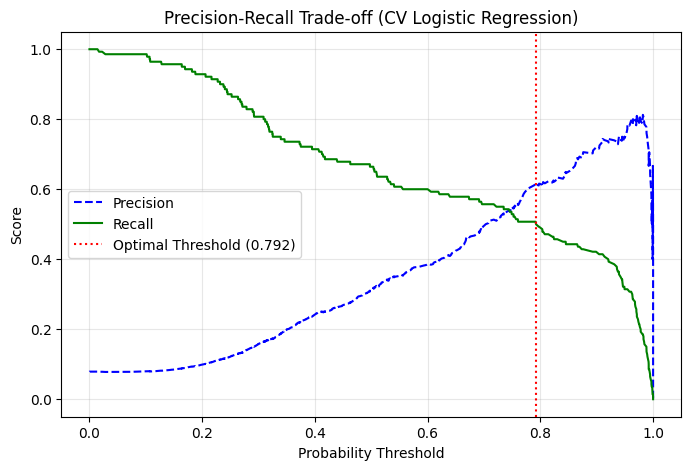

In [ ]:
## Best treshold for Logit

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import warnings
import numpy as np

# 1. Calculate precision and recall for all possible thresholds using CV Logit probabilities
precisions_log, recalls_log, thresholds_log = precision_recall_curve(y_train, train_cv_probs_logit)

# 2. Calculate F1 score for each threshold
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    f1_scores_log = 2 * (precisions_log * recalls_log) / (precisions_log + recalls_log)

# 3. Find the optimal threshold
optimal_idx_log = np.nanargmax(f1_scores_log)
optimal_threshold_log = thresholds_log[optimal_idx_log]

print(f"Optimal Threshold to maximize F1 (Cross-Validated Logit): {optimal_threshold_log:.4f}")
print("-" * 50)
print(f"  Max F1 Score : {f1_scores_log[optimal_idx_log]:.3f}")
print(f"  Precision    : {precisions_log[optimal_idx_log]:.3f}")
print(f"  Recall       : {recalls_log[optimal_idx_log]:.3f}")

# 4. Plot the curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds_log, precisions_log[:-1], 'b--', label='Precision')
plt.plot(thresholds_log, recalls_log[:-1], 'g-', label='Recall')
plt.axvline(x=optimal_threshold_log, color='r', linestyle=':', label=f'Optimal Threshold ({optimal_threshold_log:.3f})')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off (CV Logistic Regression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##Probit

In [ ]:
# ─────────────────────────────────────────────
# 0. THE FIX: RE-BUILD THE MATRICES
# ─────────────────────────────────────────────
RATIO_COLS = [c for c in train_r.columns if c != "firm_id"]
X_train = train_r[RATIO_COLS].values
y_train = train["target"].values
X_test  = test_r[RATIO_COLS].values

# ─────────────────────────────────────────────
# 2. THE STATISTICIAN: CROSS-VALIDATED PROBIT
# ─────────────────────────────────────────────
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import statsmodels.api as sm
import numpy as np
import warnings

# Custom wrapper to force statsmodels Probit to play nice with sklearn Pipelines
class SklearnProbit(BaseEstimator, ClassifierMixin):
    def __init__(self, method='bfgs', maxiter=100):
        self.method = method
        self.maxiter = maxiter

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        # Statsmodels requires an explicit intercept column
        X_const = sm.add_constant(X, has_constant='add')
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            self.model_ = sm.Probit(y, X_const).fit(disp=0, method=self.method, maxiter=self.maxiter)
        return self

    def predict_proba(self, X):
        X_const = sm.add_constant(X, has_constant='add')
        probs = self.model_.predict(X_const)
        probs = np.nan_to_num(probs, nan=0.0, posinf=1.0, neginf=0.0) # Safety net for collinearity
        return np.column_stack([1 - probs, probs])

    def predict(self, X):
        # ---> THE CURE: Dummy predict method to satisfy sklearn's validation rail <---
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print("Running 5-Fold Cross-Validation for Probit Regression...")

probit_model_stack = Pipeline([
    ("median_filler", SimpleImputer(strategy="median")),
    ("z_score_scaler", StandardScaler()), # Critical for Probit convergence
    ("probit_algorithm", SklearnProbit(method='bfgs', maxiter=100))
])

# 1. Set up the strict 5-fold cross-validation rules
cv_rules = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Get OUT-OF-SAMPLE probabilities for the entire training set
train_cv_probs_probit = cross_val_predict(
    probit_model_stack, X_train, y_train, cv=cv_rules, method="predict_proba", n_jobs=-1
)[:, 1]

# ---> MANUAL THRESHOLD DIAL: Adjust this to hit your exact target numbers! <---
probit_threshold = 0.2913

# 3. Generate the final 0s and 1s array for the Ensemble Stack
pred_train_probit = (train_cv_probs_probit >= probit_threshold).astype(int)

# 4. Fit the model once on the full data to predict the final Test/Submission set
probit_model_stack.fit(X_train, y_train)
test_probs_probit = probit_model_stack.predict_proba(X_test)[:, 1]
pred_test_probit  = (test_probs_probit >= probit_threshold).astype(int)

# 5. Print the strict Cross-Validated Metrics
print(f"── 5-Fold CV Probit Evaluation (Threshold = {probit_threshold}) ──")
print(f"  Recall (Defaults Caught) : {recall_score(y_train, pred_train_probit):.3f}")
print(f"  Precision (Accuracy of 1s): {precision_score(y_train, pred_train_probit, zero_division=0):.3f}")
print(f"  F1 Score                 : {f1_score(y_train, pred_train_probit):.3f}")
print(f"  Overall Accuracy         : {accuracy_score(y_train, pred_train_probit):.3f}")

Running 5-Fold Cross-Validation for Probit Regression...
── 5-Fold CV Probit Evaluation (Threshold = 0.2913) ──
  Recall (Defaults Caught) : 0.529
  Precision (Accuracy of 1s): 0.597
  F1 Score                 : 0.561
  Overall Accuracy         : 0.935


Running 5-Fold Cross-Validation for Probit Regression...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Optimal Threshold to maximize F1 (Cross-Validated Probit): 0.2913
--------------------------------------------------
  Max F1 Score : 0.553
  Precision    : 0.589
  Recall       : 0.521


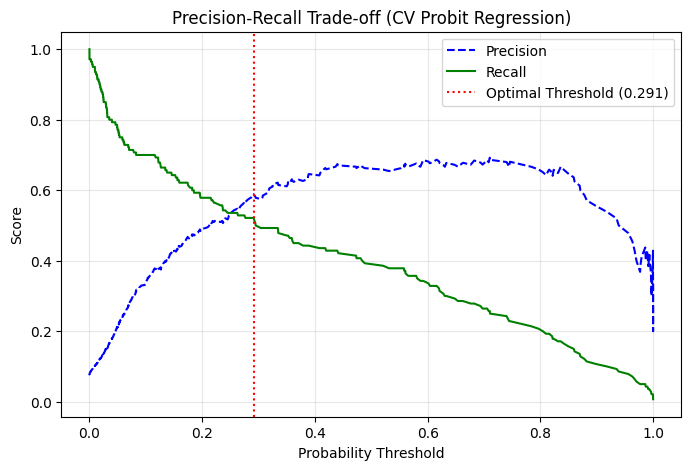

In [ ]:
## Best treshold for Probit

from sklearn.metrics import precision_recall_curve
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
import numpy as np

print("Running 5-Fold Cross-Validation for Probit Regression...")

# ─────────────────────────────────────────────
# 0. RE-BUILD THE MATRICES (Safety Net)
# ─────────────────────────────────────────────
RATIO_COLS = [c for c in train_r.columns if c != "firm_id"]
X_train = train_r[RATIO_COLS].values
y_train = train["target"].values

# 1. Clean and scale the data
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_clean = imputer.fit_transform(X_train)
X_train_scaled = scaler.fit_transform(X_train_clean) # Fixed typo here
X_train_const = sm.add_constant(X_train_scaled)

# 2. Setup 5-Fold Cross Validation
cv_rules = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_cv_probs_probit = np.zeros(len(y_train))

# Manually loop through folds to get pure Out-Of-Sample Probit probabilities
for train_idx, val_idx in cv_rules.split(X_train_const, y_train):
    X_tr, y_tr = X_train_const[train_idx], y_train[train_idx]
    X_val = X_train_const[val_idx]

    # Fit the Probit model on the training folds using statsmodels
    probit_model = sm.Probit(y_tr, X_tr).fit(disp=0, maxiter=100)

    # Predict on the left-out valuation fold
    train_cv_probs_probit[val_idx] = probit_model.predict(X_val)

# 3. Calculate precision and recall for all possible thresholds
precisions_prob, recalls_prob, thresholds_prob = precision_recall_curve(y_train, train_cv_probs_probit)

# 4. Calculate F1 score for each threshold
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    f1_scores_prob = 2 * (precisions_prob * recalls_prob) / (precisions_prob + recalls_prob)

# 5. Find the optimal threshold
optimal_idx_prob = np.nanargmax(f1_scores_prob)
optimal_threshold_prob = thresholds_prob[optimal_idx_prob]

print(f"Optimal Threshold to maximize F1 (Cross-Validated Probit): {optimal_threshold_prob:.4f}")
print("-" * 50)
print(f"  Max F1 Score : {f1_scores_prob[optimal_idx_prob]:.3f}")
print(f"  Precision    : {precisions_prob[optimal_idx_prob]:.3f}")
print(f"  Recall       : {recalls_prob[optimal_idx_prob]:.3f}")

# 6. Plot the curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds_prob, precisions_prob[:-1], 'b--', label='Precision')
plt.plot(thresholds_prob, recalls_prob[:-1], 'g-', label='Recall')
plt.axvline(x=optimal_threshold_prob, color='r', linestyle=':', label=f'Optimal Threshold ({optimal_threshold_prob:.3f})')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off (CV Probit Regression)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Random Forest part


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import numpy as np

print("Running 5-Fold Cross-Validation for Random Forest...")

# ─────────────────────────────────────────────
# 0. RE-BUILD THE MATRICES
# ─────────────────────────────────────────────
RATIO_COLS = [c for c in train_r.columns if c != "firm_id"]
X_train = train_r[RATIO_COLS].values
y_train = train["target"].values

# 1. Clean the data (handling NaNs via median imputation)
imputer = SimpleImputer(strategy="median")
X_train_clean = imputer.fit_transform(X_train)

# 2. Setup 5-Fold Stratified Cross Validation rules
cv_rules = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_cv_probs_rf = np.zeros(len(y_train))

# 3. Execute the manual fold loop to populate out-of-sample probabilities
for train_idx, val_idx in cv_rules.split(X_train_clean, y_train):
    X_tr, y_tr = X_train_clean[train_idx], y_train[train_idx]
    X_val = X_train_clean[val_idx]

    # Train using class_weight='balanced' (No SMOTE/synthetic data rows!)
    rf_model = RandomForestClassifier(
                    n_estimators=300,
                    max_depth=7,
                    class_weight="balanced",
                    min_samples_leaf=10,
                    random_state=42,
                    n_jobs=-1
                )
    rf_model.fit(X_tr, y_tr)

    # Store probabilities from the left-out validation fold
    train_cv_probs_rf[val_idx] = rf_model.predict_proba(X_val)[:, 1]

print("Cross-validation complete! Out-of-sample probabilities successfully stored in 'train_cv_probs_rf'.\n")

# ─────────────────────────────────────────────
# 4. FIXED THRESHOLD EVALUATION
# ─────────────────────────────────────────────
rf_threshold = 0.5089 #0.5367#0.4503
pred_train_rf = (train_cv_probs_rf >= rf_threshold).astype(int)

print(f"── 5-Fold CV Random Forest Evaluation (Threshold = {rf_threshold}) ──")
print(f"  Recall (Defaults Caught) : {recall_score(y_train, pred_train_rf):.3f}")
print(f"  Precision (Accuracy of 1s): {precision_score(y_train, pred_train_rf, zero_division=0):.3f}")
print(f"  F1 Score                 : {f1_score(y_train, pred_train_rf):.3f}")
print(f"  Overall Accuracy         : {accuracy_score(y_train, pred_train_rf):.3f}")

Running 5-Fold Cross-Validation for Random Forest...
Cross-validation complete! Out-of-sample probabilities successfully stored in 'train_cv_probs_rf'.

── 5-Fold CV Random Forest Evaluation (Threshold = 0.5089) ──
  Recall (Defaults Caught) : 0.671
  Precision (Accuracy of 1s): 0.443
  F1 Score                 : 0.534
  Overall Accuracy         : 0.908


Finding optimal threshold for Random Forest probabilities...
Optimal Threshold to maximize F1 (Cross-Validated Random Forest): 0.6156
--------------------------------------------------
  Max F1 Score : 0.556
  Precision    : 0.562
  Recall       : 0.550


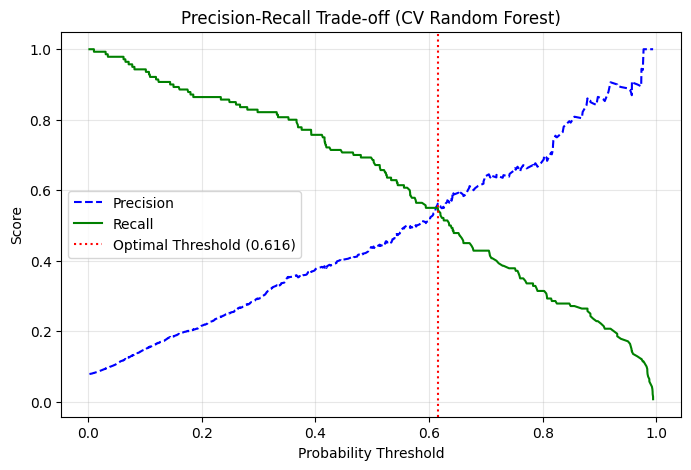

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import warnings
import numpy as np

print("Finding optimal threshold for Random Forest probabilities...")

# 1. Calculate precision and recall for all possible thresholds
precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_train, train_cv_probs_rf)

# 2. Calculate F1 score for each threshold step
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    f1_scores_rf = 2 * (precisions_rf * recalls_rf) / (precisions_rf + recalls_rf)

# 3. Isolate the index and value of the highest F1 score
optimal_idx_rf = np.nanargmax(f1_scores_rf)
optimal_threshold_rf = thresholds_rf[optimal_idx_rf]

# 4. Print the exact maximum cross-validated metrics
print(f"Optimal Threshold to maximize F1 (Cross-Validated Random Forest): {optimal_threshold_rf:.4f}")
print("-" * 50)
print(f"  Max F1 Score : {f1_scores_rf[optimal_idx_rf]:.3f}")
print(f"  Precision    : {precisions_rf[optimal_idx_rf]:.3f}")
print(f"  Recall       : {recalls_rf[optimal_idx_rf]:.3f}")

# 5. Plot the visualization
plt.figure(figsize=(8, 5))
plt.plot(thresholds_rf, precisions_rf[:-1], 'b--', label='Precision')
plt.plot(thresholds_rf, recalls_rf[:-1], 'g-', label='Recall')
plt.axvline(x=optimal_threshold_rf, color='r', linestyle=':', label=f'Optimal Threshold ({optimal_threshold_rf:.3f})')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off (CV Random Forest)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final result

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
import numpy as np

print("Aggregating the board of directors for the final CV vote...")

# ─────────────────────────────────────────────
# 1. THE ENSEMBLE ENGINE (Majority Vote)
# ─────────────────────────────────────────────
def majority_vote(*preds):
    """
    Takes a variable number of 0/1 arrays, stacks them,
    and returns 1 if at least half + 1 vote for default.
    """
    stack = np.stack(preds, axis=1)
    # Since we have 3 models, sum >= 2 means a majority agreement
    return (stack.sum(axis=1) >= 2).astype(int)

# ─────────────────────────────────────────────
# 2. RUN THE OUT-OF-SAMPLE TRAIN VOTE (Cross-Validated)
# ─────────────────────────────────────────────
# This blends the 5-Fold CV outputs you generated in your other cells
train_ensemble_cv = majority_vote(train_altman_pred, pred_train_logit, pred_train_rf)

# ─────────────────────────────────────────────
# 3. PRINT THE OFFICIAL CROSS-VALIDATED PERFORMANCE
# ─────────────────────────────────────────────
print("\n" + "="*55)
print("FINAL ENSEMBLE 5-FOLD CROSS-VALIDATION PERFORMANCE")
print("="*55)
print(f"  Recall (Defaults Caught) : {recall_score(y_train, train_ensemble_cv):.3f}")
print(f"  Precision (Accuracy of 1s): {precision_score(y_train, train_ensemble_cv, zero_division=0):.3f}")
print(f"  F1 Score                 : {f1_score(y_train, train_ensemble_cv):.3f}")
print(f"  Overall Accuracy         : {accuracy_score(y_train, train_ensemble_cv):.3f}")
print("="*55)

Aggregating the board of directors for the final CV vote...

FINAL ENSEMBLE 5-FOLD CROSS-VALIDATION PERFORMANCE
  Recall (Defaults Caught) : 0.500
  Precision (Accuracy of 1s): 0.654
  F1 Score                 : 0.567
  Overall Accuracy         : 0.940


Total Firms Flagged for Default by Ensemble (k >= 2): 104

  k = 0 -> 1602 firms (Unanimous SAFE (0 models flagged))
  k = 1 ->   74 firms (Minority Concern (1 model flagged - Ignored))
  k = 2 ->   63 firms (MAJORITY DEFAULT (2 models flagged - Triggered))
  k = 3 ->   41 firms (Unanimous DEFAULT (3 models flagged - Triggered))

Generating visual distribution plot...


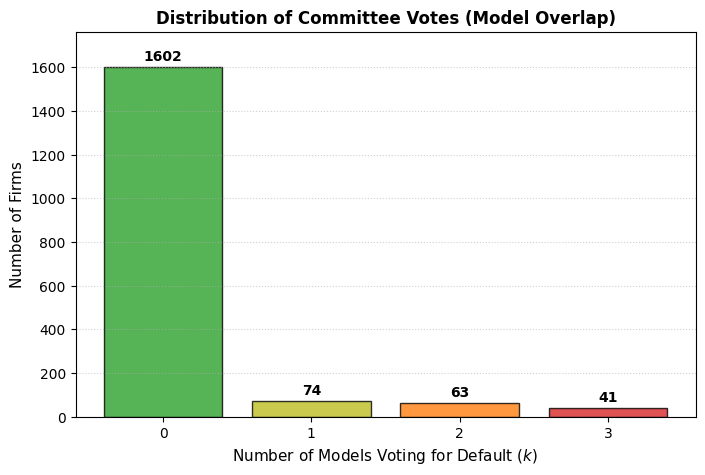

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate k exactly as specified
k = train_altman_pred + pred_train_logit + pred_train_rf

# 2. Compute the exact frequencies for 0, 1, 2, and 3
# Reindexing ensures all buckets appear even if a count happens to be zero
counts = pd.Series(k).value_counts().reindex([0, 1, 2, 3], fill_value=0)

print("=======================================================")
# Calculate the total flags that your majority ensemble actually triggered (k >= 2)
total_ensemble_defaults = counts[2] + counts[3]
print(f"Total Firms Flagged for Default by Ensemble (k >= 2): {total_ensemble_defaults}")
print("=======================================================\n")

# Print the breakdown
for vote_count, num_firms in counts.items():
    agreement_type = {
        0: "Unanimous SAFE (0 models flagged)",
        1: "Minority Concern (1 model flagged - Ignored)",
        2: "MAJORITY DEFAULT (2 models flagged - Triggered)",
        3: "Unanimous DEFAULT (3 models flagged - Triggered)"
    }[vote_count]
    print(f"  k = {vote_count} -> {num_firms:4d} firms ({agreement_type})")

print("\nGenerating visual distribution plot...")

# 3. Plot the discrete distribution bar chart
plt.figure(figsize=(8, 5))
# Custom color palette transitioning from safe (green) to dangerous (red)
colors = ['#2ca02c', '#bcbd22', '#ff7f0e', '#d62728']

bars = plt.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels directly on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + (max(counts.values) * 0.01),
        f'{int(yval)}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.xlabel('Number of Models Voting for Default ($k$)', fontsize=11)
plt.ylabel('Number of Firms', fontsize=11)
plt.title('Distribution of Committee Votes (Model Overlap)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.ylim(0, max(counts.values) * 1.1) # Add room on top for text labels
plt.show()

     📢 COMMITTEE RELIABILITY REPORT: WHEN THEY AGREE, ARE THEY RIGHT?

▶️ When k = 0 Models Voted for Default [Ensemble Decision: SAFE (0)]
   Total Firms in Category : 1543
   ✔️  CORRECT Decisions    : 1500 firms
   ❌  WRONG Decisions      : 43 firms (Missed Defaulters (False Negatives))
   🎯  Bucket Hit Rate     : 97.21%

▶️ When k = 1 Models Voted for Default [Ensemble Decision: SAFE (0)]
   Total Firms in Category : 130
   ✔️  CORRECT Decisions    : 103 firms
   ❌  WRONG Decisions      : 27 firms (Missed Defaulters (False Negatives))
   🎯  Bucket Hit Rate     : 79.23%

▶️ When k = 2 Models Voted for Default [Ensemble Decision: DEFAULT (1)]
   Total Firms in Category : 60
   ✔️  CORRECT Decisions    : 33 firms
   ❌  WRONG Decisions      : 27 firms (False Alarms (False Positives))
   🎯  Bucket Hit Rate     : 55.00%

▶️ When k = 3 Models Voted for Default [Ensemble Decision: DEFAULT (1)]
   Total Firms in Category : 47
   ✔️  CORRECT Decisions    : 37 firms
   ❌  WRONG Decisions     

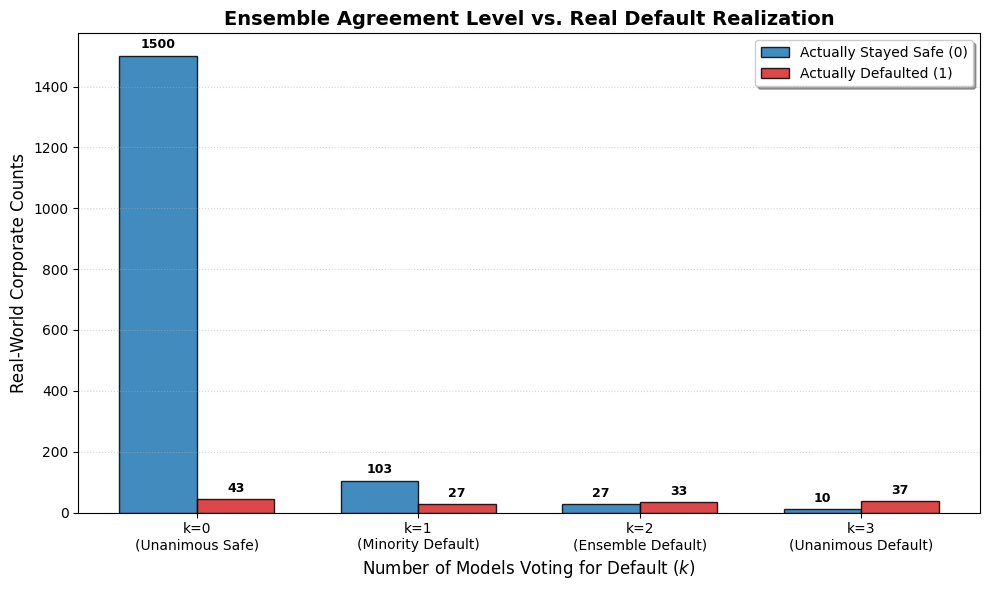

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate k exactly as your pipeline specifies
k = train_altman_pred + pred_train_logit + pred_train_rf

# 2. Build an alignment dataframe to map votes against real history
df_diagnostic = pd.DataFrame({
    'Votes_k': k,
    'Actual_Outcome': y_train
})

# 3. Generate a contingency cross-tabulation table
# Rows: k (0 to 3), Columns: Actual Outcome (0 = Stayed Safe, 1 = Defaulted)
crosstab = pd.crosstab(df_diagnostic['Votes_k'], df_diagnostic['Actual_Outcome']).reindex([0, 1, 2, 3], fill_value=0)

# Safety check to make sure both columns exist in the output table
if 0 not in crosstab.columns: crosstab[0] = 0
if 1 not in crosstab.columns: crosstab[1] = 0

print("=" * 75)
print("     📢 COMMITTEE RELIABILITY REPORT: WHEN THEY AGREE, ARE THEY RIGHT?")
print("=" * 75 + "\n")

# 4. Calculate track records row by row
for vote in [0, 1, 2, 3]:
    total_firms = crosstab.loc[vote].sum()
    actual_safe = crosstab.loc[vote, 0]
    actual_default = crosstab.loc[vote, 1]

    if total_firms == 0:
        print(f"k = {vote} -> No firms landed in this bucket.\n")
        continue

    # Determine what the ensemble officially decided for this bucket
    if vote >= 2:
        ensemble_decision = "DEFAULT (1)"
        correct_calls = actual_default
        wrong_calls = actual_safe
        error_label = "False Alarms (False Positives)"
    else:
        ensemble_decision = "SAFE (0)"
        correct_calls = actual_safe
        wrong_calls = actual_default
        error_label = "Missed Defaulters (False Negatives)"

    hit_rate = (correct_calls / total_firms) * 100

    print(f"▶️ When k = {vote} Models Voted for Default [Ensemble Decision: {ensemble_decision}]")
    print(f"   Total Firms in Category : {total_firms}")
    print(f"   ✔️  CORRECT Decisions    : {correct_calls} firms")
    print(f"   ❌  WRONG Decisions      : {wrong_calls} firms ({error_label})")
    print(f"   🎯  Bucket Hit Rate     : {hit_rate:.2f}%\n")

print("=" * 75)

# 5. Visualizing the Truth Matrix
print("\nGenerating conditional performance chart...")
plt.figure(figsize=(10, 6))

x_axis = np.arange(4)
width = 0.35

# Plot historical safe vs default counts side-by-side for each k bucket
bar_safe = plt.bar(x_axis - width/2, crosstab[0], width, label='Actually Stayed Safe (0)', color='#1f77b4', edgecolor='black', alpha=0.85)
bar_def  = plt.bar(x_axis + width/2, crosstab[1], width, label='Actually Defaulted (1)', color='#d62728', edgecolor='black', alpha=0.85)

# Add text value labels to the bars
for bars in [bar_safe, bar_def]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2., height + (max(df_diagnostic['Votes_k'].value_counts()) * 0.01),
                     f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

#plt.figure(figsize=(5,4 ))
plt.xlabel('Number of Models Voting for Default ($k$)', fontsize=12)
plt.ylabel('Real-World Corporate Counts', fontsize=12)
plt.title('Ensemble Agreement Level vs. Real Default Realization', fontsize=14, fontweight='bold')
plt.xticks(x_axis, ['k=0\n(Unanimous Safe)', 'k=1\n(Minority Default)', 'k=2\n(Ensemble Default)', 'k=3\n(Unanimous Default)'])
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Soultions


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import numpy as np

RATIO_COLS = [c for c in train_r.columns if c != "firm_id"]
X_train = train_r[RATIO_COLS].values
y_train = train["target"].values
X_test  = test_r[RATIO_COLS].values

imputer = SimpleImputer(strategy="median")
X_train_clean = imputer.fit_transform(X_train)
X_test_clean  = imputer.transform(X_test)

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight="balanced",
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_clean, y_train)
test_probs_rf = rf_final.predict_proba(X_test_clean)[:, 1]
pred_test_rf  = (test_probs_rf >= 0.5089).astype(int)

print("RF done:", pred_test_rf.sum(), "defaults predicted")

RF done: 53 defaults predicted


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np

ensemble_stack     = np.stack([test_altman_pred, pred_test_logit, pred_test_rf], axis=1)
test_ensemble_pred = (ensemble_stack.sum(axis=1) >= 2).astype(int)

submission = pd.read_excel("/content/sample_data/challenge_submission_file.xlsx")
submission["predicted_label"] = test_ensemble_pred
print(submission["predicted_label"].value_counts())
submission.to_excel("challenge_submission_final.xlsx", index=False)
files.download("challenge_submission_final.xlsx")

predicted_label
0    417
1     29
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>